In [1]:
#load the dataset
import pandas as pd
df=pd.read_csv("sales_data_with_discounts.csv")

In [2]:
df

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174


In [3]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [4]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64'])
print("Numerical Columns:")
print(numerical_columns.columns)

Numerical Columns:
Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')


In [5]:
#Calculate Mean, Median, Mode, and Standard Deviation
# Mean
mean = numerical_columns.mean()

# Median
median = numerical_columns.median()

# Mode
mode = numerical_columns.mode().iloc[0]

# Standard Deviation
std = numerical_columns.std()

# Combine results into one table
statistics = pd.DataFrame({
    "Mean": mean,
    "Median": median,
    "Mode": mode,
    "Standard Deviation": std
})

print(statistics)

                           Mean       Median          Mode  Standard Deviation
Volume                 5.066667     4.000000      3.000000            4.231602
Avg Price          10453.433333  1450.000000    400.000000        18079.904840
Total Sales Value  33812.835556  5700.000000  24300.000000        50535.074173
Discount Rate (%)     15.155242    16.577766      5.007822            4.220602
Discount Amount     3346.499424   988.933733     69.177942         4509.902963
Net Sales Value    30466.336131  4677.788059    326.974801        46358.656624


Interpretation:
The calculated mean, median, mode, and standard deviation summarize the central tendency and variability of the numerical variables. Comparing these measures helps identify the typical values, the spread of the data, and whether the distribution is symmetric or affected by skewness and outliers.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("sales_data_with_discounts.csv")

In [7]:
#Identify Numerical and Categorical Columns
# Numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
# Categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print("Numerical Columns:")
print(numerical_columns)
print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

Categorical Columns:
Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


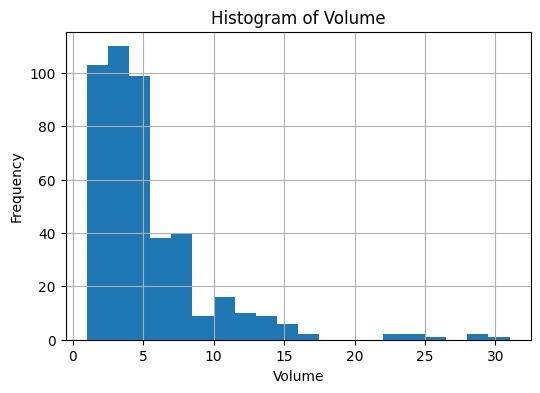

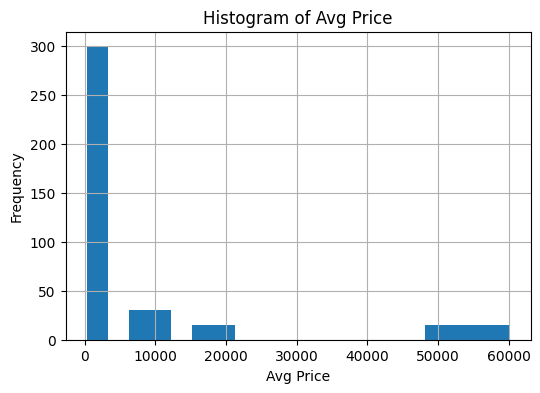

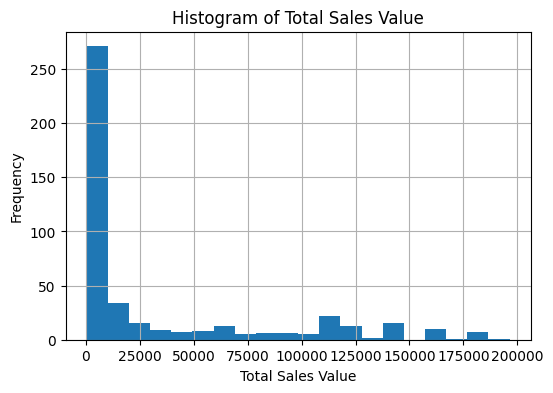

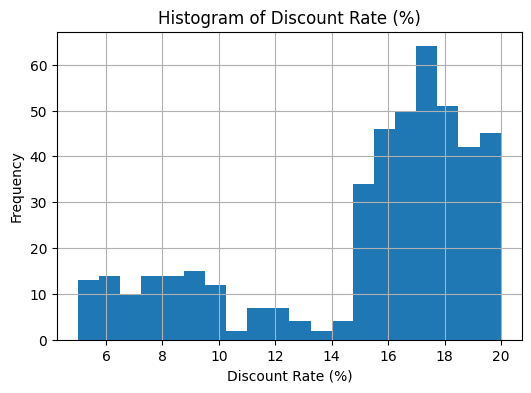

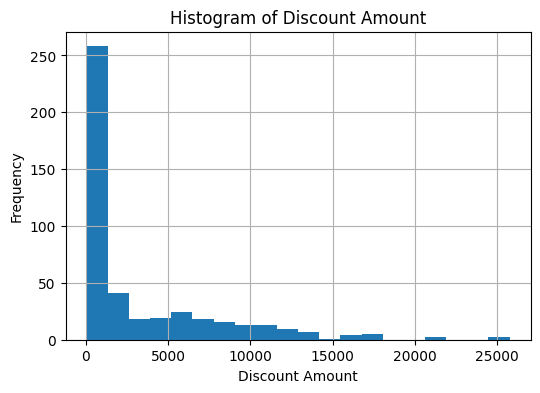

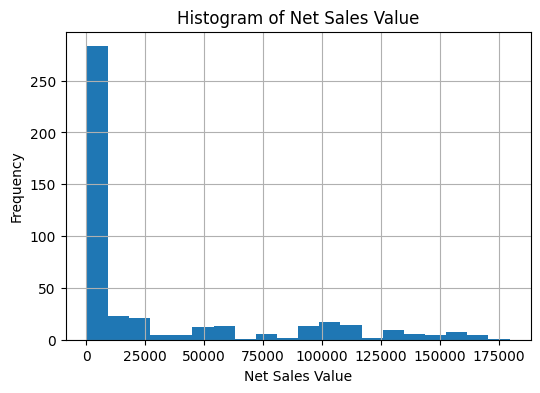

In [8]:
#Histograms
for column in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[column], bins=20)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

Histogram Interpretation

The histograms show the distribution of numerical variables, helping identify their spread, central tendency, and skewness. Most variables are concentrated around a central range, while any long tails or isolated bars may indicate skewness or the presence of outliers.

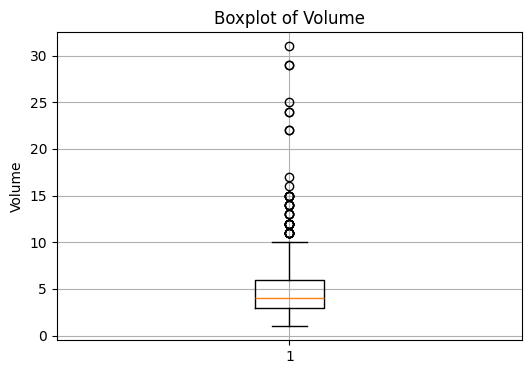

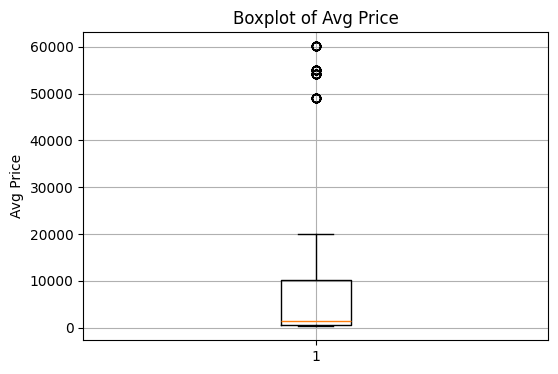

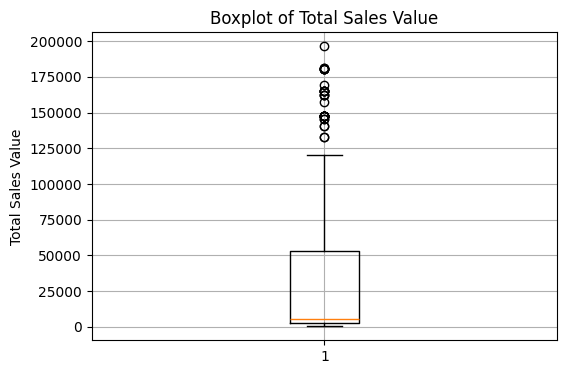

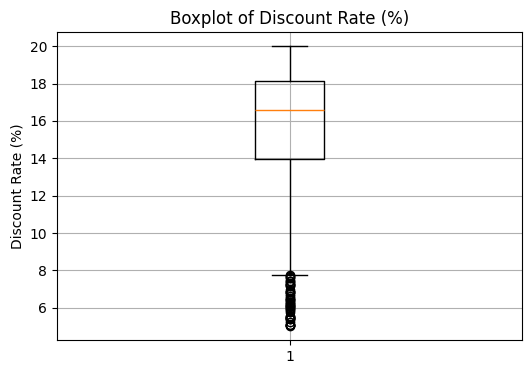

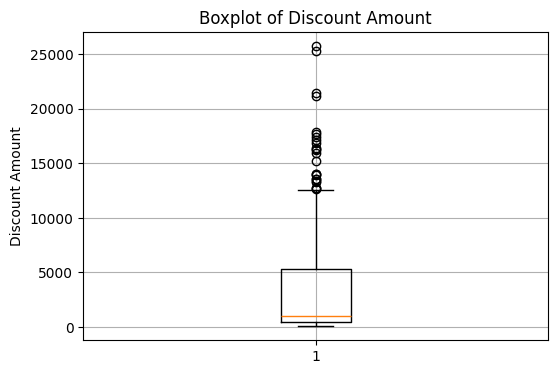

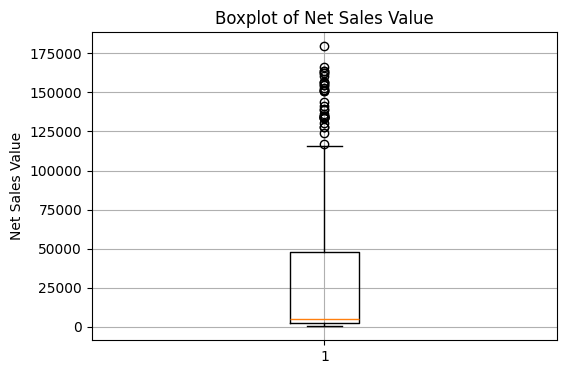

In [17]:
#Boxplots
for column in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[column], vert=True)
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

Boxplot Interpretation

The boxplots summarize the distribution of numerical variables by displaying the median, interquartile range (IQR), and potential outliers. Variables with points outside the whiskers indicate extreme values that may require further investigation

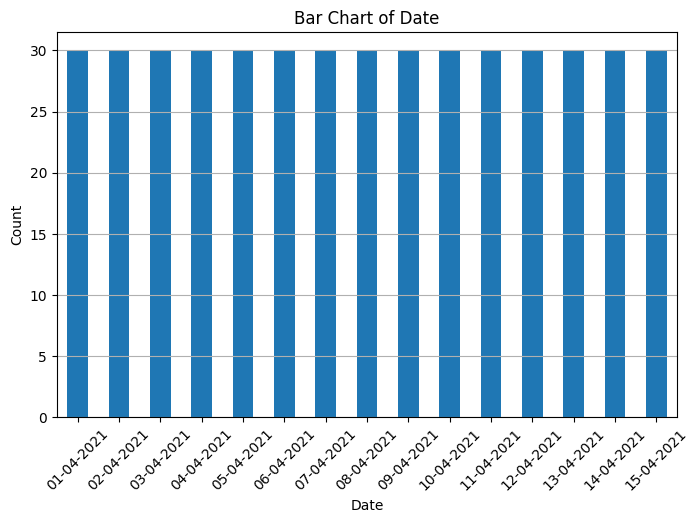

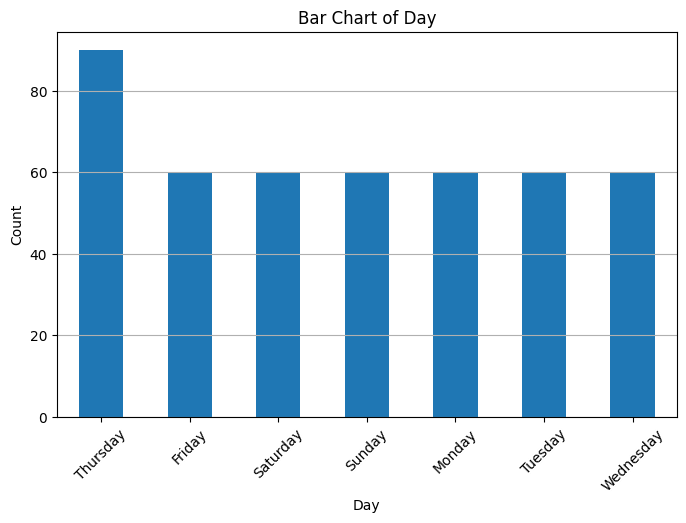

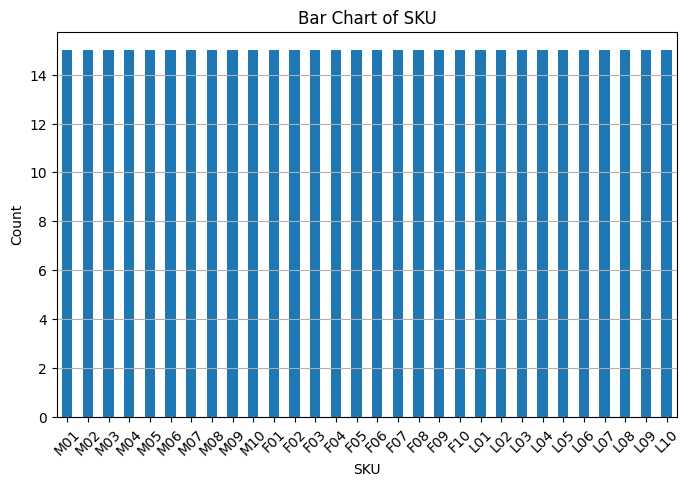

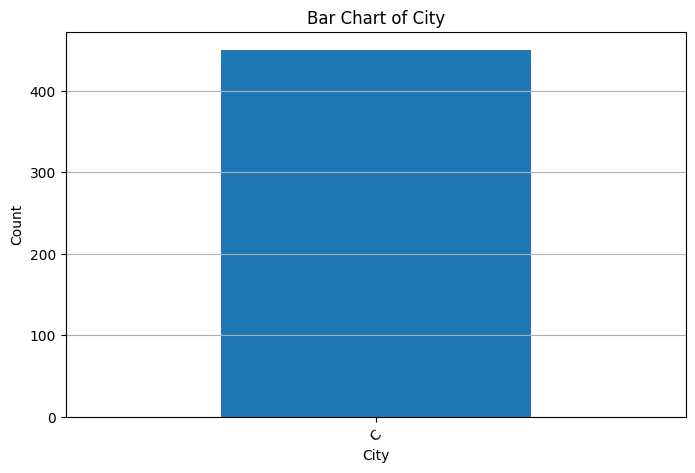

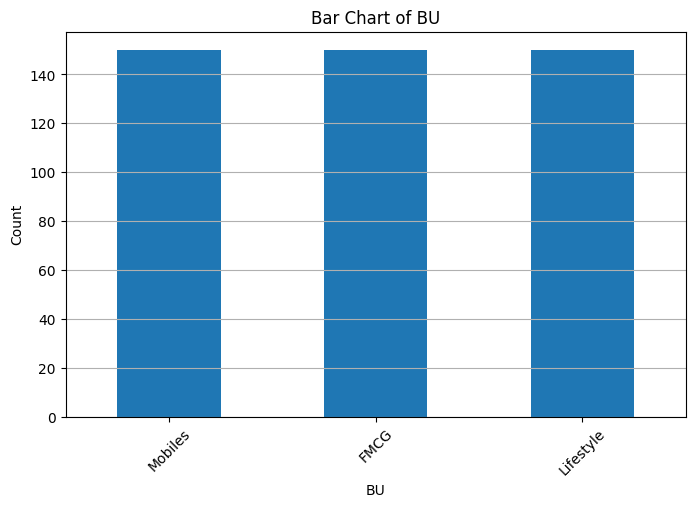

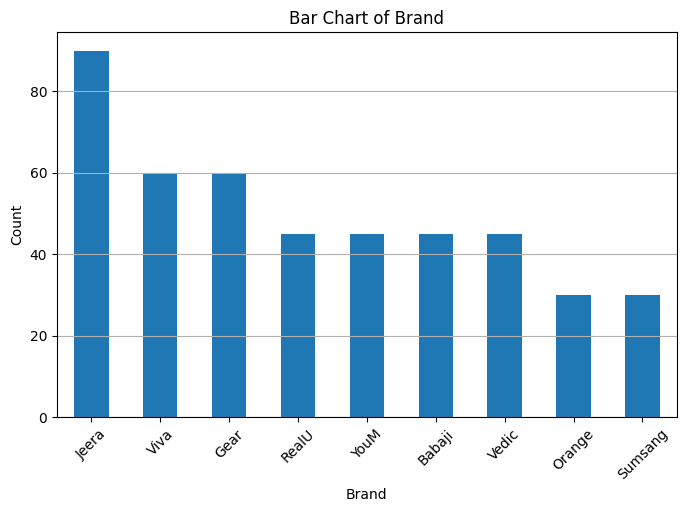

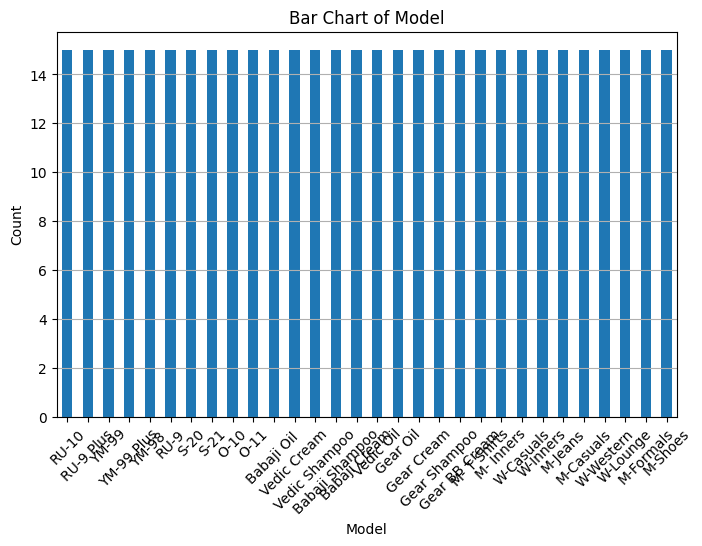

In [10]:
#Plot Bar Charts
for column in categorical_columns:
    plt.figure(figsize=(8,5))
    df[column].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()

Bar Chart Interpretation

The bar charts display the frequency of each category in the categorical variables. They help identify the most and least frequent categories, showing whether the data is evenly distributed or dominated by specific categories.

In [11]:
# Standardize the numerical columns
df_standardized = df.copy()

for column in numerical_columns:
    mean = df[column].mean()
    std = df[column].std()
    df_standardized[column] = (df[column] - mean) / std

print("Original DataFrame head:")
display(df.head())
print("\nStandardized DataFrame head:")
display(df_standardized.head())

Original DataFrame head:


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770



Standardized DataFrame head:


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,2.347417,Mobiles,RealU,RU-10,0.091072,2.922469,-0.829365,3.948422,2.801638
1,01-04-2021,Thursday,M02,C,1.165831,Mobiles,RealU,RU-9 Plus,-0.019548,1.329516,-0.851714,1.846958,1.269613
2,01-04-2021,Thursday,M03,C,0.456880,Mobiles,YouM,YM-99,0.312312,1.561038,-1.350129,1.621190,1.543957
3,01-04-2021,Thursday,M04,C,0.220563,Mobiles,YouM,YM-99 Plus,0.533552,1.717365,-1.947555,1.112568,1.763847
4,01-04-2021,Thursday,M05,C,-0.488389,Mobiles,YouM,YM-98,-0.130168,-0.188242,0.672990,0.227598,-0.227342


Interpretation:
The numerical variables were standardized using Z-score normalization, which transformed each feature to have a mean close to 0 and a standard deviation close to 1. This removes differences in scale while preserving the original distribution, making the dataset more suitable for statistical analysis and machine learning algorithms.

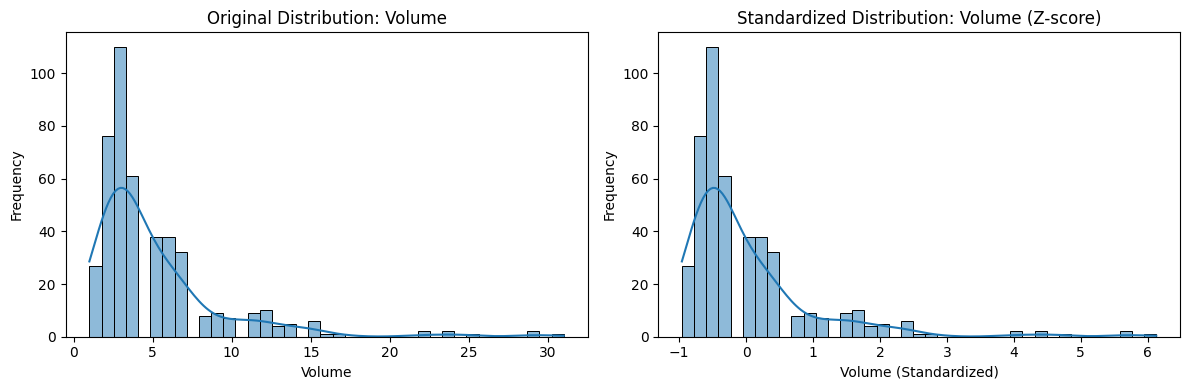

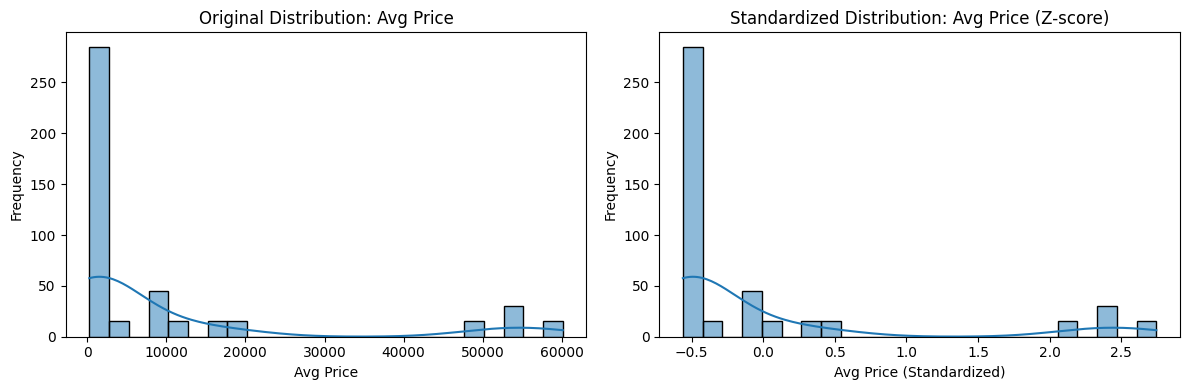

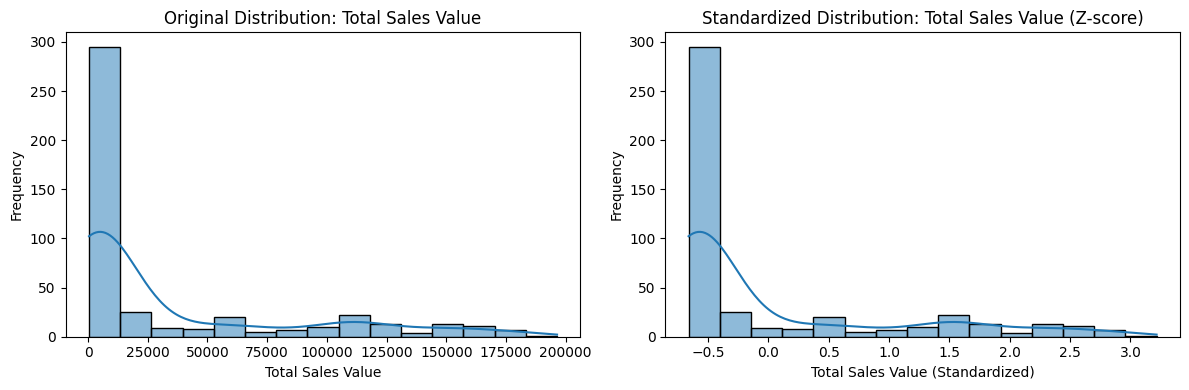

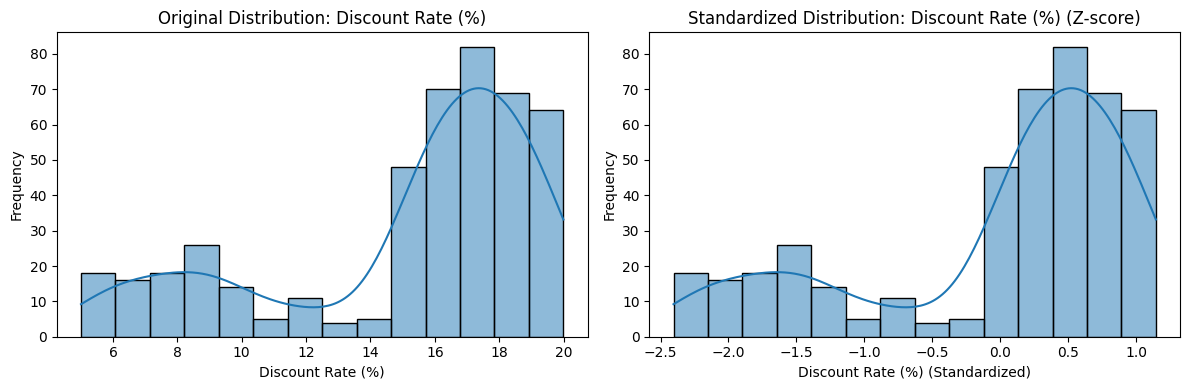

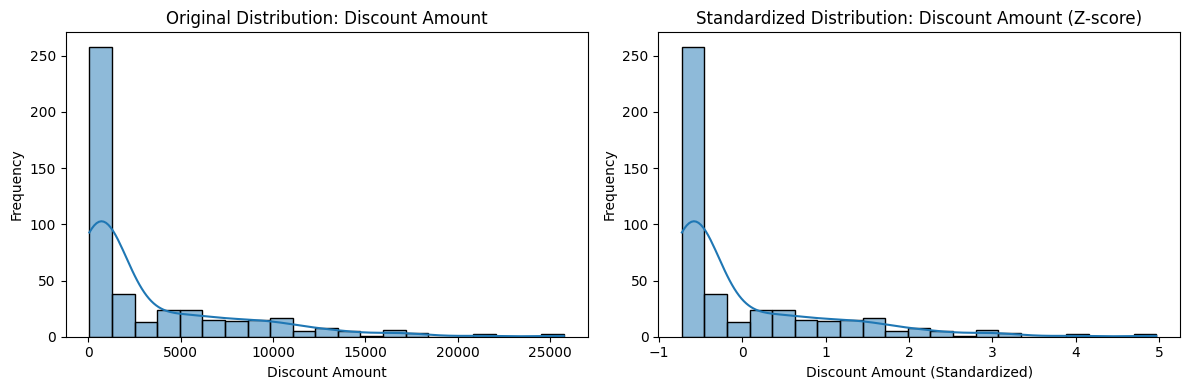

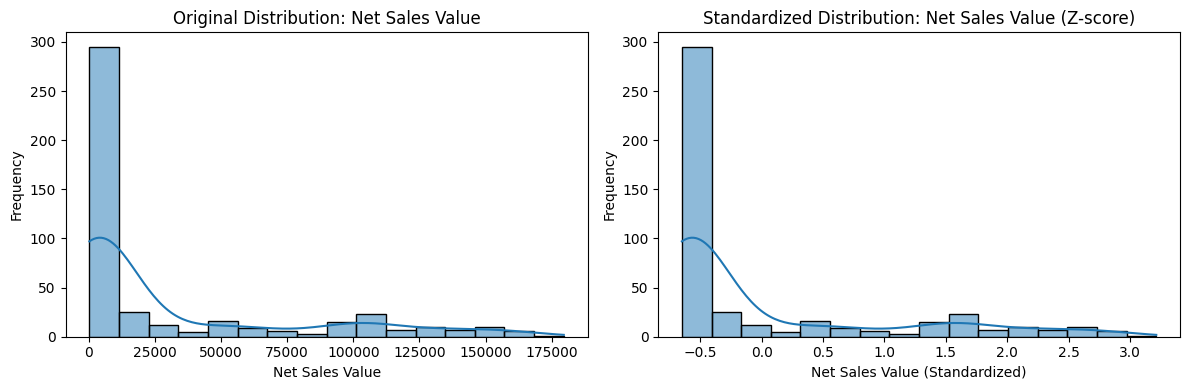

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in numerical_columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Before standardization
    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Original Distribution: {column}')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')

    # After standardization
    sns.histplot(df_standardized[column], kde=True, ax=axes[1])
    axes[1].set_title(f'Standardized Distribution: {column} (Z-score)')
    axes[1].set_xlabel(f'{column} (Standardized)')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [14]:
import pandas as pd

# Load dataset
df = pd.read_csv("sales_data_with_discounts.csv")

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print("Categorical Columns:")
print(categorical_columns)

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns)

# Display transformed dataset
print("\nTransformed Dataset:")
print(df_encoded.head())

Categorical Columns:
Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

Transformed Dataset:
   Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      15      12100             181500          11.654820     21153.498820   
1      10      10100             101000          11.560498     11676.102961   
2       7      16100             112700           9.456886     10657.910157   
3       6      20100             120600           6.935385      8364.074702   
4       3       8100              24300          17.995663      4372.946230   

   Net Sales Value  Date_01-04-2021  Date_02-04-2021  Date_03-04-2021  \
0    160346.501180             True            False            False   
1     89323.897039             True            False            False   
2    102042.089843             True            False            False   
3    112235.925298             True            False            False   
4     19927.053770             True    

Interpretation:
The categorical variables were successfully converted into dummy (binary) variables using one-hot encoding. Each category is represented by a separate column with values of 0 or 1, making the dataset fully numerical and suitable for machine learning algorithms without losing the original categorical information.

In [16]:
df_encoded.to_csv('dummy_df.csv', index=False)